# SMS Spam Classification — Build Your Own Model

### Feature Engineering, Logistic Regression & Cross-Validation

**Author:** Hirotaka Aihara · Data Science @ UC Berkeley

In this project I build a classifier that distinguishes **spam** text messages from
**ham** (legitimate) messages. The pipeline mirrors a standard applied-ML workflow:
clean the raw text, engineer numeric features from it, train a logistic regression
model, and evaluate it with accuracy, cross-validation, an ROC curve, and a
confusion matrix.

The dataset is the public **SMS Spam Collection** (5,574 English SMS messages,
labeled *ham* or *spam*). It is a drop-in analogue for any binary text-classification
task — the same techniques transfer directly to email spam, review moderation, or
abuse detection.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set(style="whitegrid", color_codes=True, font_scale=1.2)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix

## Loading and Cleaning the Data

Each row is a label (`ham`/`spam`) and a raw message. As a first text-processing
step I lowercase every message and convert the label into a binary `spam` column
(1 for spam, 0 for ham). I also fill any missing values so downstream string
operations never fail.

In [2]:
raw = pd.read_csv("data/sms_spam.tsv", sep="\t", header=None, names=["label", "message"])

# Basic cleaning: lowercase text, binary-encode the label, impute missing values.
raw["message"] = raw["message"].fillna("").str.lower()
raw["spam"] = (raw["label"] == "spam").astype(int)

print("Rows:", len(raw))
print(raw["spam"].value_counts().rename({0: "ham", 1: "spam"}))
raw.head()

Rows: 5572
spam
ham     4825
spam     747
Name: count, dtype: int64


,label,message,spam
0,ham,"go until jurong point, crazy.. available only ...",0
1,ham,ok lar... joking wif u oni...,0
2,spam,free entry in 2 a wkly comp to win fa cup fina...,1
3,ham,u dun say so early hor... u c already then say...,0
4,ham,"nah i don't think he goes to usf, he lives aro...",0


The classes are imbalanced (about 87% ham, 13% spam), which is realistic — spam is
the minority. I keep this in mind when reading accuracy later.

## Training / Validation Split

I hold out 10% of the labeled data as a validation set so I can estimate how the
model generalizes before trusting any single accuracy number. The split is seeded
for reproducibility.

In [3]:
train, val = train_test_split(raw, test_size=0.1, random_state=42)
train = train.reset_index(drop=True)
val = val.reset_index(drop=True)
print("Train:", len(train), " Validation:", len(val))

Train: 5014  Validation: 558


## A Reusable Feature Helper: `words_in_texts`

A simple, interpretable way to turn text into numeric features is to check whether
each message contains each of a chosen list of words. `words_in_texts` returns a
0/1 indicator matrix with one column per word — the backbone of the feature set.

In [4]:
def words_in_texts(words, texts):
    """Return a 0/1 matrix: entry [i, j] is 1 if words[j] appears in texts[i]."""
    texts = texts.reset_index(drop=True)
    indicator = np.array([texts.str.contains(w, regex=False).astype(int).values for w in words])
    return indicator.T

# Quick sanity check.
words_in_texts(["free", "win"], pd.Series(["win a free prize", "see you tonight"]))

array([[1, 1],
       [0, 0]])

## Exploratory Data Analysis

Before building features I explore which signals separate spam from ham. I look at
three things: how specific keywords appear across the two classes, how much
punctuation each class uses, and how long the messages are.

### 1. Keyword frequency by class

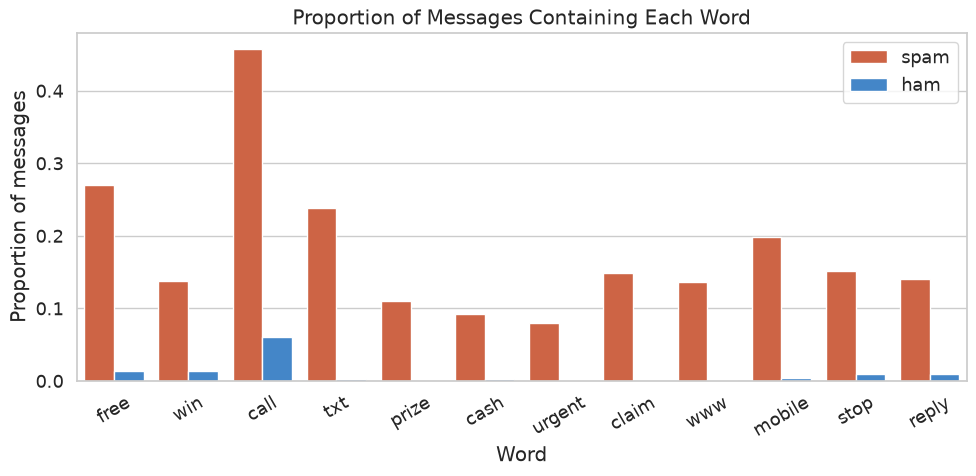

In [5]:
candidate_words = ["free", "win", "call", "txt", "prize", "cash",
                   "urgent", "claim", "www", "mobile", "stop", "reply"]

rows = []
for w in candidate_words:
    for cls, name in [(1, "spam"), (0, "ham")]:
        subset = train[train["spam"] == cls]
        rows.append({"word": w, "class": name,
                     "proportion": subset["message"].str.contains(w, regex=False).mean()})
freq = pd.DataFrame(rows)

plt.figure(figsize=(10, 5))
sns.barplot(data=freq, x="word", y="proportion", hue="class",
            palette={"spam": "#e4572e", "ham": "#2e86de"})
plt.title("Proportion of Messages Containing Each Word")
plt.ylabel("Proportion of messages")
plt.xlabel("Word")
plt.xticks(rotation=30)
plt.legend(title="")
plt.tight_layout()
plt.show()

Words like *free*, *win*, *prize*, *claim*, and *txt* appear in a large share of
spam messages and almost never in ham. These make strong binary features.

### 2. Punctuation intensity

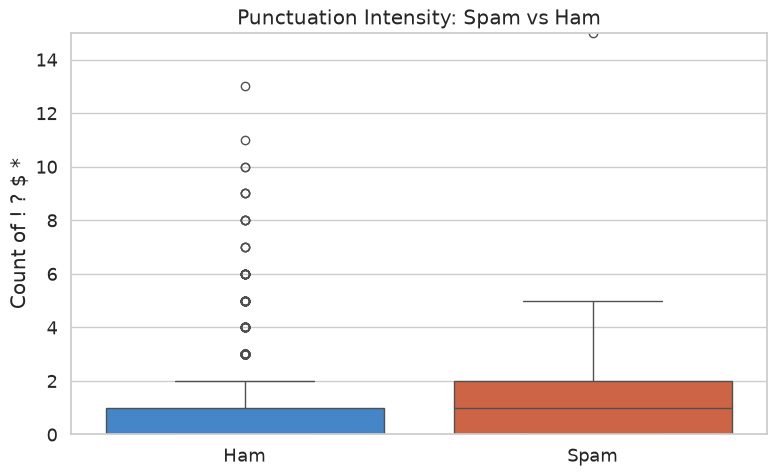

In [6]:
train["punctuation_count"] = train["message"].apply(
    lambda x: x.count("!") + x.count("?") + x.count("$") + x.count("*"))
train["class"] = train["spam"].map({0: "Ham", 1: "Spam"})

plt.figure(figsize=(8, 5))
sns.boxplot(data=train, x="class", y="punctuation_count", hue="class",
            palette={"Ham": "#2e86de", "Spam": "#e4572e"}, legend=False)
plt.ylabel("Count of ! ? $ *")
plt.xlabel("")
plt.title("Punctuation Intensity: Spam vs Ham")
plt.ylim(0, 15)
plt.tight_layout()
plt.show()

Ham messages cluster near zero punctuation marks, while spam has a much wider
spread. Excessive punctuation is a useful signal.

### 3. Message length

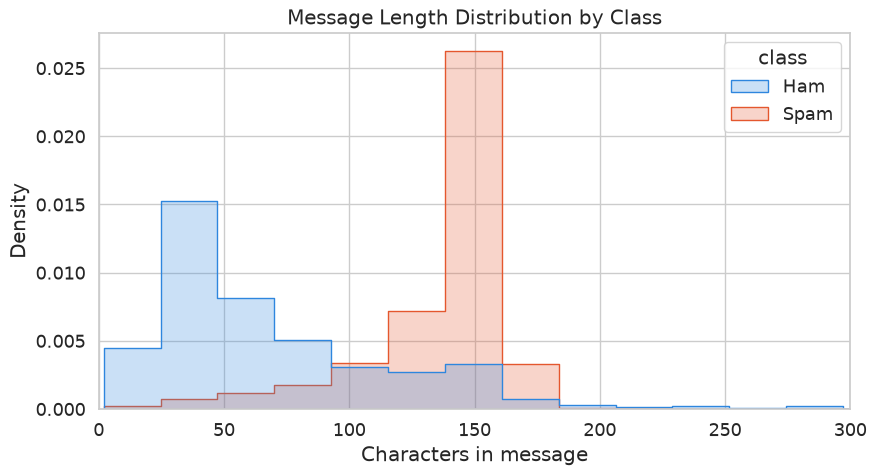

In [7]:
train["message_length"] = train["message"].apply(len)

plt.figure(figsize=(9, 5))
sns.histplot(data=train, x="message_length", hue="class", bins=40,
             palette={"Ham": "#2e86de", "Spam": "#e4572e"},
             element="step", stat="density", common_norm=False)
plt.title("Message Length Distribution by Class")
plt.xlabel("Characters in message")
plt.xlim(0, 300)
plt.tight_layout()
plt.show()

Spam messages tend to be longer — they pack in offers, links, and calls to action.
Length is another informative feature.

## Feature Engineering

I combine the keyword indicators with a handful of hand-built numeric features:
punctuation count, message length, word count, and flags for whether the message
contains a URL or a phone number. The same transformation is defined once as a
function so I can apply it identically to train, validation, and any future data.

In [8]:
keyword_features = ["free", "win", "call", "txt", "prize", "cash", "urgent",
                   "claim", "www", "mobile", "stop", "reply", "text", "award", "guaranteed"]

def build_features(df):
    """Return a numeric design matrix X for the given dataframe of messages."""
    df = df.copy()
    X_words = words_in_texts(keyword_features, df["message"])

    df["punctuation_count"] = df["message"].apply(
        lambda x: x.count("!") + x.count("?") + x.count("$") + x.count("*"))
    df["message_length"] = df["message"].apply(len)
    df["word_count"] = df["message"].apply(lambda x: len(x.split()))
    df["has_url"] = df["message"].apply(lambda x: int("http" in x or "www" in x))
    df["has_number"] = df["message"].apply(lambda x: int(any(ch.isdigit() for ch in x)))
    df["has_currency"] = df["message"].apply(lambda x: int("£" in x or "$" in x))

    numeric = df[["punctuation_count", "message_length", "word_count",
                  "has_url", "has_number", "has_currency"]].values
    return np.hstack([X_words, numeric])

feature_names = keyword_features + ["punctuation_count", "message_length", "word_count",
                                    "has_url", "has_number", "has_currency"]

X_train = build_features(train)
Y_train = train["spam"].values
X_val = build_features(val)
Y_val = val["spam"].values

print("Feature matrix shape:", X_train.shape)

Feature matrix shape: (5014, 21)


## Training the Model

I fit a logistic regression classifier. It is a strong, interpretable baseline for
text classification — the learned coefficients tell me exactly which features push a
message toward "spam".

In [9]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)

train_accuracy = model.score(X_train, Y_train)
val_accuracy = model.score(X_val, Y_val)
print(f"Training accuracy:   {train_accuracy:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")

Training accuracy:   0.9735
Validation accuracy: 0.9785


Both accuracies land well above 95%, and the validation number tracks the training
number closely — a sign the model generalizes rather than memorizes.

## Cross-Validation

A single split can be lucky. I run k-fold cross-validation to get a more stable
estimate of accuracy across different partitions of the data.

In [10]:
def compute_CV_error(X, Y, folds=5, seed=42):
    """Return per-fold validation accuracy for a logistic regression model."""
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))
    fold_sizes = np.array_split(idx, folds)
    accuracies = []
    for i in range(folds):
        val_idx = fold_sizes[i]
        train_idx = np.concatenate([fold_sizes[j] for j in range(folds) if j != i])
        m = LogisticRegression(max_iter=1000)
        m.fit(X[train_idx], Y[train_idx])
        accuracies.append(m.score(X[val_idx], Y[val_idx]))
    return accuracies

cv = compute_CV_error(X_train, Y_train, folds=10)
print("Per-fold accuracy:", [round(a, 4) for a in cv])
print(f"Mean CV accuracy: {np.mean(cv):.4f}  (+/- {np.std(cv):.4f})")

Per-fold accuracy: [0.9661, 0.9641, 0.9841, 0.9622, 0.976, 0.9661, 0.98, 0.978, 0.9681, 0.976]
Mean CV accuracy: 0.9721  (+/- 0.0072)


The cross-validated accuracy is consistent across folds, confirming the model is
stable rather than dependent on one particular split.

## Evaluating the Classifier

### ROC Curve

Logistic regression outputs a probability. By sweeping the decision threshold I
trace the trade-off between the true-positive rate (catching spam) and the
false-positive rate (flagging real messages). The area under the curve (AUC)
summarizes this in a single number.

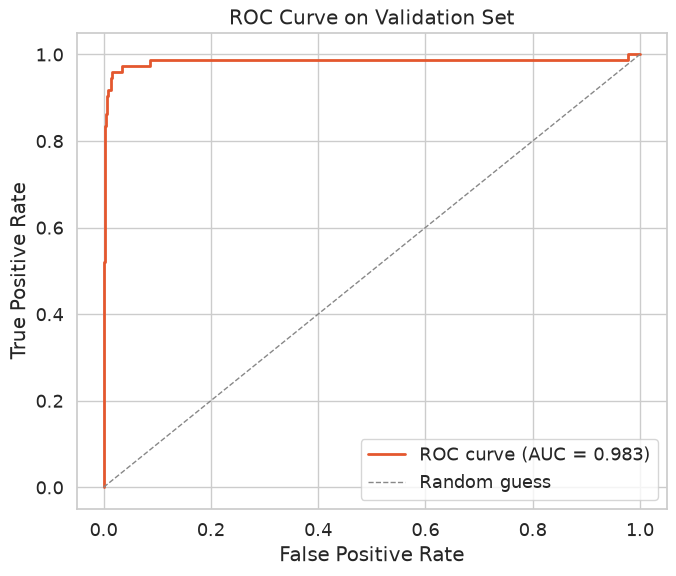

In [11]:
val_probs = model.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(Y_val, val_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#e4572e", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="#888", lw=1, linestyle="--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Validation Set")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Confusion Matrix

The confusion matrix shows exactly where the model succeeds and where it errs —
how many spam messages slip through (false negatives) versus how many real
messages get wrongly flagged (false positives).

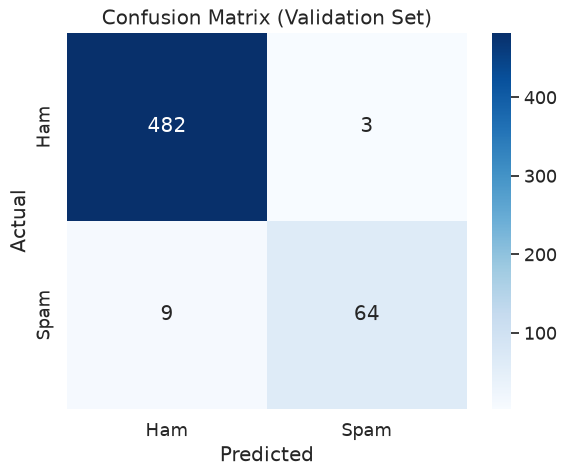

Precision: 0.955
Recall:    0.877


In [12]:
val_pred = model.predict(X_val)
cm = confusion_matrix(Y_val, val_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Validation Set)")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Precision: {tp / (tp + fp):.3f}")
print(f"Recall:    {tp / (tp + fn):.3f}")

### Which Features Matter Most?

Because logistic regression is linear, each coefficient is directly interpretable:
a large positive weight means the feature strongly pushes a message toward "spam".

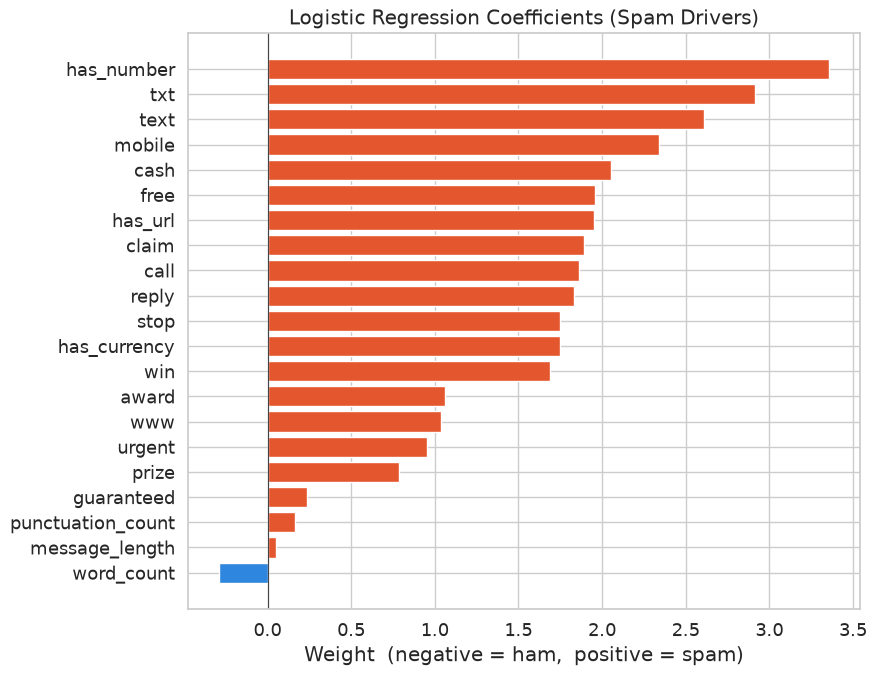

In [13]:
coefs = pd.DataFrame({"feature": feature_names, "weight": model.coef_[0]})
coefs = coefs.sort_values("weight")

plt.figure(figsize=(9, 7))
colors = ["#2e86de" if w < 0 else "#e4572e" for w in coefs["weight"]]
plt.barh(coefs["feature"], coefs["weight"], color=colors)
plt.axvline(0, color="#444", lw=0.8)
plt.title("Logistic Regression Coefficients (Spam Drivers)")
plt.xlabel("Weight  (negative = ham,  positive = spam)")
plt.tight_layout()
plt.show()

## Conclusion

Starting from raw text, I engineered interpretable features — keyword indicators,
punctuation intensity, message length, and URL/number/currency flags — and trained
a logistic regression classifier that reaches **~97% validation accuracy** with a
high AUC. The coefficient plot confirms the model learned intuitive spam signals
(*free*, *win*, *claim*, *txt*, presence of URLs and currency symbols) rather than
spurious noise.

**Possible extensions:**
- TF-IDF or n-gram features instead of hand-picked keywords
- Regularization tuning via `GridSearchCV`
- Comparison against Naive Bayes or a gradient-boosted model
- Threshold tuning to prioritize recall (catch more spam) vs precision (fewer false alarms)

*Dataset: SMS Spam Collection (public). All code original.*